# 05 — Reflexão v2: prompts novos e feedback com o gabarito (ARC + LogiQA2)

Os notebooks `03_diagnostico_reflexao_arc_validacao.ipynb` e
`04_diagnostico_reflexao_logiqa2_validacao.ipynb` (ver
[[reflection_mcq_diagnostico_notebook]] na memória do projeto) diagnosticaram, sem gerar
nenhuma reflexão nova, se existia algum `k`/limiar de similaridade em que a reflexão já gravada
batesse o baseline. Este notebook dá o passo seguinte: **a hipótese de trabalho é que a
qualidade da própria reflexão — o prompt que a produz e a pobreza do feedback que ela recebe
(só "certo"/"errado") — é o gargalo**, não (só) a recuperação por similaridade. Para testar
isso é preciso gerar reflexões novas, então este notebook refaz a etapa 2 (reflexão) do zero,
com duas mudanças deliberadas:

1. **Prompts de reflexão reescritos**, um para profundidade `simple` e um para `complex`
   (seção 4) — versões revisadas do que foi proposto no pedido original, com a avaliação de
   cada mudança registrada na própria seção.
2. **O feedback agora inclui o gabarito**: em vez de só "sua resposta foi CORRETA/INCORRETA",
   o professor (aqui sempre o próprio aluno — só autorreflexão, ver abaixo) recebe também a
   letra e o texto da alternativa correta. Antes, sem o gabarito, a reflexão de um erro só podia
   apontar "algo saiu errado"; com o gabarito, pode nomear a lacuna de raciocínio de verdade —
   ao custo de abrir uma porta nova para viés de retrospecto (seção 4 discute isso).

**O que NÃO muda:** o prompt de resposta (`ANSWER_PROMPT`) e o prompt de avaliação com notas
recuperadas (`build_eval_prompt`, versão `v2`) já passaram por uma rodada própria de engenharia
de prompt em sessões anteriores (ver [[reflection_mcq_prompt_refactor]]). Este notebook os
importa de `rmcq.common` sem alteração — só a etapa 2 (como a reflexão é escrita) está em jogo
aqui.

**Desenho:**

- **Modelos**: `phi4-mini` e `llama3-8b` — os dois alunos ativos do projeto. **Só
  autorreflexão** (cada um reflete sobre as próprias respostas; sem professor cruzado) —
  decisão deliberada para isolar o efeito do prompt/feedback novo sem misturar com a variável
  "quem ensina quem". `rmcq.config` já traz esses dois como `DEFAULT_ACTIVE_MODELS`.
- **Datasets**: `arc` e `logiqa2`, com seleção de dados própria deste notebook (seção 1) —
  **não** os splits oficiais de `data/splits/`, que ficam intocados:
  - **ARC**: todas as questões disponíveis, tanto no treino quanto na validação. O treino usa o
    pool inteiro deduplicado (~1.100 itens, antes da amostragem de Cochran que produziu os 286
    oficiais) em vez do subconjunto oficial; a validação usa os 298 itens oficiais (que já são
    "todos", Cochran nunca se aplicou a validação).
  - **LogiQA2**: treino maior que o oficial (372 → 1.200, amostra estratificada do mesmo pool
    deduplicado) e validação bem menor que a oficial (1.565 → 300, amostra estratificada), para
    conter o custo de GPU da grade de avaliação.
- **Pipeline**: seleção de dados → baseline (treino + validação, reaproveitando respostas
  oficiais do ARC onde o item já foi respondido) → reflexão nova (só treino, só autorreflexão,
  prompts + feedback novos) → índice de similaridade treino↔validação → grade
  `k × threshold × depth` na validação → consolidação (acurácia, reflection utility, McNemar,
  comparação com os números v1 de 03/04 quando existirem) → gráficos.

**Custo e verificação**: como em 03/04, `SMOKE_TEST = True` troca o backend real pelo
`StubBackend` (determinístico, sem GPU) e limita a poucos itens — serve para validar a
canalização inteira (seleção, prompts, geração, recuperação, métricas, gráficos) em segundos.
Este notebook foi construído e verificado ponta a ponta dessa forma, contra o pacote `rmcq` de
verdade (não um mock) com `sentence_transformers` substituído por embeddings determinísticos por
hash — não foi rodado com GPU real nem gerou nenhuma reflexão de verdade; isso é trabalho do
usuário, com `SMOKE_TEST = False`.

## 0. Setup

In [2]:
import sys
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7"  # ajuste para a GPU que for usar
import warnings
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))  # pacote rmcq

import rmcq  # carrega o .env antes de qualquer import de torch/transformers/vllm
print(rmcq.env_summary())

from rmcq.backends import GenParams, get_backend
from rmcq.common import (
    build_answer_prompt, build_eval_prompt, cochran_sample_size, format_options,
    format_question, label_distribution, make_record, read_jsonl, stratified_sample,
    strip_think, write_jsonl,
)
from rmcq.config import (
    COCHRAN_CONFIDENCE, COCHRAN_FINITE_CORRECTION, COCHRAN_MARGIN, COCHRAN_PROPORTION,
    EMBED_BATCH_SIZE, EMBEDDER, HF_HOME, PROCESSED_DIR, RESULTS_DIR, SEED, STUDENT_GEN,
    TEACHER_GEN, hf_token,
)
from rmcq.data import baseline_path, load_split
from rmcq.stages.analyze import SIM_BINS, accuracy_block, transferability, utility
from rmcq.store import JsonlStore, Timer, get_logger

log = get_logger(__name__)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (7, 4)

STUDENTS = ["phi4-mini", "llama3-8b"]      # alunos ativos em rmcq.config.ACTIVE_MODELS
DATASETS = ["arc", "logiqa2"]
DEPTHS = ["simple", "complex"]
TEACHERS_PER_STUDENT = {s: [s] for s in STUDENTS}  # so autorreflexao, de proposito (ver secao 0)

# Raiz de tudo que este notebook produz. Arvore NOVA e separada de results/baseline,
# results/reflections e results/diagnostics (que sao do pipeline oficial / de 03-04) -- nada
# aqui sobrescreve resultado nenhum ja existente, e os dois conjuntos ficam comparaveis lado a
# lado em vez de um apagar o outro.
RESULTS_V2 = RESULTS_DIR / "reflection_v2"
DATA_V2_DIR = RESULTS_V2 / "data"
BASE_V2_DIR = RESULTS_V2 / "baseline"
REFL_V2_DIR = RESULTS_V2 / "reflections"
INDEX_V2_DIR = RESULTS_V2 / "index"
DIAG_V2_DIR = RESULTS_V2 / "diagnostics"
for d in (DATA_V2_DIR, BASE_V2_DIR, REFL_V2_DIR, INDEX_V2_DIR, DIAG_V2_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- controles de execucao ---------------------------------------------------
# SMOKE_TEST = True primeiro: StubBackend (deterministico, sem GPU) + poucos itens, para
# validar a canalizacao inteira em segundos antes de gastar horas de GPU de verdade.
SMOKE_TEST = False
SMOKE_LIMIT = 8

BACKEND_KIND = "stub" if SMOKE_TEST else None   # None = usa RMCQ_BACKEND do .env (vllm)
RUN_LIMIT = SMOKE_LIMIT if SMOKE_TEST else None

print(f"students={STUDENTS}  datasets={DATASETS}  depths={DEPTHS}")
print(f"SMOKE_TEST={SMOKE_TEST}  backend_kind={BACKEND_KIND!r}  limit={RUN_LIMIT}")
print(f"raiz dos resultados deste notebook: {RESULTS_V2}")


def load_rows(path):
    store = JsonlStore(path)
    return {r["uid"]: r for r in store.read_all()} if store.exists() else {}

.env | CUDA_VISIBLE_DEVICES='7' | backend=vllm
students=['phi4-mini', 'llama3-8b']  datasets=['arc', 'logiqa2']  depths=['simple', 'complex']
SMOKE_TEST=False  backend_kind=None  limit=None
raiz dos resultados deste notebook: /home/rodrigo.flexa/Reflection-MCQ/results/reflection_v2


## 1. Seleção de dados — ARC (tudo) e LogiQA2 (1.200 treino / 300 validação)

`data/splits/` é a entrada oficial e congelada do resto do pipeline (treino do ARC amostrado
pela fórmula de Cochran, ver `01_formatacao_e_selecao.ipynb`) — este notebook não escreve nela.
Em vez disso, monta seu próprio conjunto de treino/validação por dataset, a partir de
`data/processed/` (o schema unificado, antes de qualquer amostragem), e grava o resultado em
`results/reflection_v2/data/<dataset>/` para ficar reprodutível entre execuções (a mesma seed
sempre reproduz a mesma amostra; apagar o arquivo força reamostrar).

**Política, por dataset:**

- **ARC — tudo disponível.** Treino: o pool inteiro de `data/processed/arc/train.jsonl`
  (~1.117 itens) **deduplicado contra validação e teste** (mesma lógica de
  `01_formatacao_e_selecao.ipynb`, célula "Vazamento entre treino e teste" — sem isso, um item
  de treino idêntico a um de validação inflaria a similaridade para 1.0 e a "reflexão
  recuperada" seria, na prática, a resposta colada). Validação: os 298 itens oficiais, que já
  são o total — Cochran nunca amostrou validação.
- **LogiQA2 — treino maior, validação menor que o oficial.** O oficial (372 treino / 1.565
  validação) vem de Cochran aplicado ao treino e da validação **inteira**. Aqui o treino sobe
  para **1.200** (amostra estratificada por gabarito do mesmo pool deduplicado, ~12.500 itens —
  ainda uma fração pequena dele) e a validação cai para **300** (amostra estratificada dos
  1.565 oficiais) — o objetivo é dar mais material de treino para a reflexão aprender padrões
  sem herdar o custo de rodar a grade `k × threshold` inteira sobre 1.565 itens (~5x o custo do
  ARC, como já registrado em `04_diagnostico_reflexao_logiqa2_validacao.ipynb`).

A amostragem usa `rmcq.common.stratified_sample` (a mesma função do Cochran oficial), então a
distribuição do gabarito na amostra continua próxima da população — verificado na tabela
abaixo.

In [3]:
import re


def dedup_key(item):
    """Chave de identidade de uma questao: enunciado + contexto, normalizados.

    Copia identica a de 01_formatacao_e_selecao.ipynb (celula "Vazamento entre treino e
    teste") -- nao esta em rmcq.common porque e especifica da etapa de selecao, nao do
    pipeline de geracao/avaliacao.
    """
    text = f"{item.get('context') or ''} || {item['question']}"
    return re.sub(r"\W+", " ", text.lower()).strip()


def dedup_train_pool(dataset):
    """Pool de treino deduplicado: sem colisao com validacao/teste, sem duplicata interna."""
    train_items = read_jsonl(PROCESSED_DIR / dataset / "train.jsonl")
    held_out = set()
    for split in ("validation", "test"):
        path = PROCESSED_DIR / dataset / f"{split}.jsonl"
        if path.exists():
            held_out |= {dedup_key(i) for i in read_jsonl(path)}

    seen, pool = set(), []
    for item in train_items:
        k = dedup_key(item)
        if k in held_out or k in seen:
            continue
        seen.add(k)
        pool.append(item)
    return pool, len(train_items)

In [9]:
# n=None equivale a "usa tudo": stratified_sample(pool, n=len(pool), ...) devolve o
# proprio pool sem reamostrar (ver a checagem `if n >= len(items): return list(items)` em
# rmcq.common.stratified_sample), entao a mesma chamada serve para ARC (tudo) e LogiQA2
# (subamostra) sem precisar de dois caminhos de codigo.
SELECTION_SPEC = {
    "arc":     {"train_n": None, "val_n": None},   # None = todas as disponiveis
    "logiqa2": {"train_n": 2000, "val_n": 300},
}

FORCE_RESELECT = True  # True para ignorar o cache em results/reflection_v2/data/ e reamostrar

train_selected, val_selected = {}, {}
selection_report = []

for dataset in DATASETS:
    train_path = DATA_V2_DIR / dataset / "train.jsonl"
    val_path = DATA_V2_DIR / dataset / "validation.jsonl"

    if train_path.exists() and val_path.exists() and not FORCE_RESELECT:
        train_selected[dataset] = read_jsonl(train_path)
        val_selected[dataset] = read_jsonl(val_path)
        fonte = "cache (results/reflection_v2/data/)"
    else:
        pool, n_raw = dedup_train_pool(dataset)
        train_n = SELECTION_SPEC[dataset]["train_n"] or len(pool)
        train_selected[dataset] = stratified_sample(pool, n=train_n, seed=SEED)

        official_val = read_jsonl(PROCESSED_DIR / dataset / "validation.jsonl")
        val_n = SELECTION_SPEC[dataset]["val_n"] or len(official_val)
        val_selected[dataset] = stratified_sample(official_val, n=val_n, seed=SEED)

        write_jsonl(train_path, train_selected[dataset])
        write_jsonl(val_path, val_selected[dataset])
        fonte = f"amostrado agora (pool deduplicado: {n_raw} bruto -> {len(pool)} limpo)"

    official_train_n = len(read_jsonl(PROCESSED_DIR / dataset / "train.jsonl"))
    official_val_n = len(read_jsonl(PROCESSED_DIR / dataset / "validation.jsonl"))
    selection_report.append({
        "dataset": dataset,
        "treino (v2)": len(train_selected[dataset]),
        "treino (oficial)": official_train_n,
        "validacao (v2)": len(val_selected[dataset]),
        "validacao (oficial)": official_val_n,
        "fonte": fonte,
    })

pd.DataFrame(selection_report)

,dataset,treino (v2),treino (oficial),validacao (v2),validacao (oficial),fonte
0,arc,1109,1117,298,298,amostrado agora (pool deduplicado: 1117 bruto ...
1,logiqa2,2000,12537,300,1565,amostrado agora (pool deduplicado: 12537 bruto...


In [10]:
# Verificacao de vazamento: nenhum item do treino v2 pode coincidir (por dedup_key) com a
# validacao v2 nem com o teste oficial. Trava com AssertionError se falhar -- diferente das
# checagens de "prompt divergiu" adiante, isto nao e opcional: um vazamento aqui infla a
# similaridade treino-validacao para 1.0 e finge transferencia que nao existe.
for dataset in DATASETS:
    held_out = {dedup_key(i) for i in val_selected[dataset]}
    test_path = PROCESSED_DIR / dataset / "test.jsonl"
    if test_path.exists():
        held_out |= {dedup_key(i) for i in read_jsonl(test_path)}
    overlap = [i["uid"] for i in train_selected[dataset] if dedup_key(i) in held_out]
    assert not overlap, f"{dataset}: {len(overlap)} itens de treino vazam para validacao/teste"

print("verificado: nenhum item de treino (v2) aparece em validacao (v2) ou teste, em nenhum dataset")

# Distribuicao do gabarito, populacao vs. amostra -- so muda de verdade onde ha reamostragem
# (LogiQA2; no ARC train_n=None devolve o pool inteiro, populacao == amostra).
dist_rows = []
for dataset in DATASETS:
    pool, _ = dedup_train_pool(dataset)
    dist_rows.append({
        "dataset": dataset, "conjunto": "treino",
        "dist. populacao": label_distribution(pool),
        "dist. amostra": label_distribution(train_selected[dataset]),
    })
    official_val = read_jsonl(PROCESSED_DIR / dataset / "validation.jsonl")
    dist_rows.append({
        "dataset": dataset, "conjunto": "validacao",
        "dist. populacao": label_distribution(official_val),
        "dist. amostra": label_distribution(val_selected[dataset]),
    })
pd.DataFrame(dist_rows)

verificado: nenhum item de treino (v2) aparece em validacao (v2) ou teste, em nenhum dataset


,dataset,conjunto,dist. populacao,dist. amostra
0,arc,treino,"{'A': 0.2137, 'B': 0.2642, 'C': 0.2597, 'D': 0...","{'A': 0.2137, 'B': 0.2642, 'C': 0.2597, 'D': 0..."
1,arc,validacao,"{'A': 0.2114, 'B': 0.245, 'C': 0.2617, 'D': 0....","{'A': 0.2114, 'B': 0.245, 'C': 0.2617, 'D': 0...."
2,logiqa2,treino,"{'A': 0.2261, 'B': 0.2454, 'C': 0.263, 'D': 0....","{'A': 0.226, 'B': 0.2455, 'C': 0.263, 'D': 0.2..."
3,logiqa2,validacao,"{'A': 0.2313, 'B': 0.2422, 'C': 0.2594, 'D': 0...","{'A': 0.23, 'B': 0.2433, 'C': 0.26, 'D': 0.2667}"


## 2. Prompt de resposta e prompt de avaliação com notas — inalterados

Diferente de `03`/`04`, que copiavam esses dois prompts localmente porque estavam sendo
experimentados, aqui eles **não mudam** — só a etapa de reflexão (seção 4) está em jogo nesta
rodada. Por isso são importados direto de `rmcq.common`:

- `build_answer_prompt`: o prompt de resposta congelado, usado no baseline (seção 3).
- `build_eval_prompt` (versão `v2`, `RMCQ_EVAL_PROMPT` no `.env`): como as reflexões
  recuperadas viram `<note>`s no prompt de avaliação (seção 7). Já passou pela própria rodada
  de ajuste (enquadramento antes da questão, corte por palavras, neutralização de letra — ver
  [[reflection_mcq_prompt_refactor]]).

In [11]:
_sample = val_selected["arc"][0]
print(build_answer_prompt(_sample))

You are answering a multiple-choice question.

Question: Juan and LaKeisha roll a few objects down a ramp. They want to see which object rolls the farthest. What should they do so they can repeat their investigation?

Options:
A) Put the objects in groups.
B) Change the height of the ramp.
C) Choose different objects to roll.
D) Record the details of the investigation.

Instructions:
- Think step by step before answering.
- Choose exactly one option.
- End your response with this exact line, and nothing after it:
FINAL ANSWER: <letter>


## 3. Baseline (sem reflexão) para os conjuntos de treino e validação novos

Grava em `results/reflection_v2/baseline/<modelo>/<dataset>_<split>.jsonl` — árvore própria
deste notebook, retomável do jeito de sempre (`JsonlStore`).

Duas coisas valem registrar:

- **Precisa de baseline de TREINO agora**, diferente de `03`/`04` (que só geravam baseline de
  validação porque reaproveitavam reflexões já existentes): a reflexão nova desta seção 5
  precisa saber o que o aluno respondeu no treino antes de refletir sobre isso.
- **Reaproveitamento no ARC**: o pool de treino v2 do ARC (seção 1) contém, por construção, os
  286 itens do split oficial (o oficial é uma subamostra de Cochran do mesmo pool). As respostas
  desses 286 já existem em `results/baseline/<modelo>/arc_train.jsonl` (o baseline oficial) —
  em vez de gerá-las de novo, este notebook as copia para o store novo antes de gerar as
  restantes (~830). Não há reaproveitamento equivalente para o LogiQA2 (a amostra de 1.200 é
  nova, tirada de um pool de ~12.500, com pouca sobreposição esperada com os 372 oficiais) nem
  para nenhuma validação (nenhum baseline de validação existe ainda em nenhum dos dois
  datasets — `03`/`04` também não foram rodados de verdade).

In [12]:
def run_baseline_v2(items, dataset, split, students, limit=None, backend_kind=None, reuse_official_train=False):
    params = GenParams.from_config(STUDENT_GEN, seed=SEED)
    stats = {"generated": 0, "reused": 0, "elapsed_s": 0.0}
    use_items = items[:limit] if limit else items

    for model in students:
        path = BASE_V2_DIR / model / f"{dataset}_{split}.jsonl"
        store = JsonlStore(path)

        if reuse_official_train and not store.done_keys():
            official = load_rows(baseline_path(model, dataset, "train"))
            reuse_uids = [i["uid"] for i in use_items if i["uid"] in official]
            if reuse_uids:
                store.append([official[u] for u in reuse_uids])
                stats["reused"] += len(reuse_uids)
                log.info("[%s] reaproveitadas %d respostas oficiais de %s/train", model, len(reuse_uids), dataset)

        done = store.done_keys()
        pending = [i for i in use_items if i["uid"] not in done]
        if not pending:
            log.info("[%s] %s/%s ja completo (%d itens)", model, dataset, split, len(use_items))
            continue

        with Timer() as timer, get_backend(model, backend_kind) as backend:
            prompts = [build_answer_prompt(i) for i in pending]
            gens = backend.generate(prompts, params, desc=f"{model} baseline-v2 {dataset}/{split}")

            records = [
                make_record(
                    item, stage="baseline", condition="no_reflection", student_model=model,
                    prompt=prompt, output=gen.text,
                    prompt_tokens=gen.prompt_tokens, completion_tokens=gen.completion_tokens,
                    latency_s=gen.latency_s, seed=SEED, temperature=params.temperature,
                )
                for item, prompt, gen in zip(pending, prompts, gens)
            ]
            store.append(records)
            stats["generated"] += len(records)
            n_ok = sum(1 for r in records if r.is_correct)
            log.info("[%s] %s/%s: gravado %d, acerto %.1f%%", model, dataset, split, len(records), 100 * n_ok / max(len(records), 1))
        stats["elapsed_s"] += timer.elapsed

    return stats


for dataset in DATASETS:
    print(f"--- {dataset}: baseline de treino ---")
    run_baseline_v2(
        train_selected[dataset], dataset, "train", STUDENTS,
        limit=RUN_LIMIT, backend_kind=BACKEND_KIND, reuse_official_train=(dataset == "arc"),
    )
    print(f"--- {dataset}: baseline de validacao ---")
    run_baseline_v2(val_selected[dataset], dataset, "validation", STUDENTS, limit=RUN_LIMIT, backend_kind=BACKEND_KIND)

--- arc: baseline de treino ---


00:40:12 INFO    carregando phi4-mini (microsoft/Phi-4-mini-instruct) via vLLM  tp=1  gpu_util=0.60


INFO 08-27 00:40:13 [api_utils.py:273] non-default args: {'tokenizer': 'microsoft/Phi-4-mini-instruct', 'download_dir': '/home/rodrigo.flexa/Reflection-MCQ/models/hf_cache', 'dtype': 'bfloat16', 'seed': 42, 'max_model_len': 8192, 'gpu_memory_utilization': 0.6, 'disable_log_stats': True, 'model': 'microsoft/Phi-4-mini-instruct'}


[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


INFO 08-27 00:40:14 [model.py:645] Resolved architecture: Phi3ForCausalLM
INFO 08-27 00:40:14 [model.py:1883] Using max model len 8192
INFO 08-27 00:40:14 [scheduler.py:242] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 08-27 00:40:14 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
(EngineCore pid=996203) INFO 08-27 00:40:20 [core.py:121] Initializing a V1 LLM engine (v0.27.1) with config: model='microsoft/Phi-4-mini-instruct', speculative_config=None, tokenizer='microsoft/Phi-4-mini-instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=8192, download_dir='/home/rodrigo.flexa/Reflection-MCQ/models/hf_cache', load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_re

...

(EngineCore pid=1009344) INFO 08-27 00:48:18 [model_runner.py:791] Graph capturing finished in 6 secs, took 0.56 GiB
(EngineCore pid=1009344) INFO 08-27 00:48:18 [gpu_worker.py:789] Free memory on device (78.84/79.25 GiB) on startup. Desired GPU memory utilization is (0.6, 47.55 GiB). Actual usage is 15.21 GiB for consumed memory (weights + non-torch), 0.84 GiB for peak activation, and 0.56 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=33054938215` (30.78 GiB) to fit into requested memory, or `--kv-cache-memory=66647289344` (62.07 GiB) to fully utilize gpu memory. Current kv cache memory in use is 31.49 GiB.
(EngineCore pid=1009344) INFO 08-27 00:48:20 [jit_monitor.py:79] Kernel JIT monitor activated; monitored JIT compilations during inference will use mode=warn.
(EngineCore pid=1009344) INFO 08-27 00:48:20 [core.py:348] init engine (profile, create kv cache, warmup model) took 12.07 s (compilation: 0.28 s)
(EngineCore pid=1009344) INFO 08-27 

00:48:21 INFO      max_model_len=8192


Rendering prompts:   0%|          | 0/300 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 300/300 [00:11<00:00, 25.93it/s, est. speed input: 6375.54 toks/s, output: 2245.40 toks/s]
00:48:32 INFO      300 prompts, 25978 tokens gerados em 11.6s (2233 tok/s)
00:48:33 INFO    liberando llama3-8b


INFO 08-27 00:48:33 [utils.py:612] [shutdown] Process manager: send sigterm to process EngineCore
(EngineCore pid=1009344) INFO 08-27 00:48:33 [core.py:1332] [shutdown] EngineCore: trigger received signal=SIGTERM
(EngineCore pid=1009344) INFO 08-27 00:48:33 [core.py:1468] [shutdown] EngineCore: start mode=abort timeout=0s
(EngineCore pid=1009344) INFO 08-27 00:48:33 [core.py:1499] [shutdown] EngineCore: request processing complete; starting resource teardown
(EngineCore pid=1009344) INFO 08-27 00:48:33 [core.py:1345] [shutdown] EngineCore: exiting busy loop


In [13]:
baseline_train_v2 = {(m, d): load_rows(BASE_V2_DIR / m / f"{d}_train.jsonl") for m in STUDENTS for d in DATASETS}
baseline_val_v2 = {(m, d): load_rows(BASE_V2_DIR / m / f"{d}_validation.jsonl") for m in STUDENTS for d in DATASETS}

baseline_summary_rows = []
for m in STUDENTS:
    for d in DATASETS:
        baseline_summary_rows.append({"dataset": d, "student": m, "split": "train", **accuracy_block(list(baseline_train_v2[(m, d)].values()))})
        baseline_summary_rows.append({"dataset": d, "student": m, "split": "validation", **accuracy_block(list(baseline_val_v2[(m, d)].values()))})

pd.DataFrame(baseline_summary_rows)[["dataset", "student", "split", "n", "n_answered", "n_correct", "accuracy", "accuracy_answered"]]

,dataset,student,split,n,n_answered,n_correct,accuracy,accuracy_answered
0,arc,phi4-mini,train,1109,1108,988,0.8909,0.8917
1,arc,phi4-mini,validation,298,298,257,0.8624,0.8624
2,logiqa2,phi4-mini,train,2000,1976,1065,0.5325,0.5390
3,logiqa2,phi4-mini,validation,300,299,160,0.5333,0.5351
4,arc,llama3-8b,train,1109,1106,963,0.8683,0.8707
5,arc,llama3-8b,validation,298,297,252,0.8456,0.8485
6,logiqa2,llama3-8b,train,2000,1993,1100,0.5500,0.5519
7,logiqa2,llama3-8b,validation,300,298,165,0.5500,0.5537


## 4. Prompts de reflexão novos — com feedback que inclui o gabarito

### 4.1 O que foi proposto

O pedido original trazia um prompt para `simple` e um para `complex`, os dois já estruturados
em tópicos fixos (Approach/Key factor/Error-Success/Lesson na versão simples;
Interpretation/Strategy/Evidence/Assumptions/Alternatives/Diagnosis/Improvement/Lesson na
complexa) e os dois avisando que o professor agora recebe **qual era a alternativa correta**,
não só um booleano de acerto/erro.

**O que a proposta já acerta, e por quê vale manter:**

- **Estrutura em tópicos fixos**, em vez de "escreva uma reflexão" livre. As reflexões
  atualmente gravadas (`results/reflections/`) são narrativas soltas — é o que motiva o corte
  por palavras e a neutralização de letra em `rmcq/common.py` (ver os comentários da seção
  "v2: layout revisto para modelos pequenos"). Uma reflexão que já sai organizada em tópicos dá
  menos trabalho para o pós-processamento e, mais importante, empurra `phi4-mini` e
  `llama3-8b` — modelos pequenos — a cobrir todos os ângulos em vez de só narrar o que
  aconteceu.
- **"A lição precisa dizer o que fazer diferente, não 'preste mais atenção'"** — esta instrução
  já existia informalmente no projeto e aqui fica explícita. Reflexões vagas são inúteis para
  recuperação por similaridade: uma lição genérica não ajuda mais numa questão nova do que
  nenhuma lição.
- **Pedir para não resolver a questão de novo nem revelar a resposta correta** — importante
  MAIS AINDA agora que o feedback inclui o gabarito (seção 4.2): sem essa instrução, o caminho
  de menor esforço para um modelo pequeno é simplesmente escrever "a resposta certa era C
  porque...", que não é uma lição, é um resumo do gabarito.

**O que foi ajustado, e por quê:**

1. **Comprimento-alvo em `complex` também.** O rascunho dava um alvo de frases só para
   `simple` ("3–5 sentences"); `complex` ficava aberto. As reflexões `complex` já gravadas têm
   mediana de ~615 palavras (LogiQA2) — é exatamente o que motivou o corte agressivo em
   `compact_reflection()`. Um alvo explícito ("8–12 sentences, roughly 150–220 words") ataca o
   problema na geração, não depois por corte.
2. **A instrução final vira uma linha só, num formato fixo: `"Lesson: <regra geral>"`.**
   `compact_reflection()` corta pela CAUDA quando a reflexão passa do limite de palavras — é o
   comentário do próprio `rmcq/common.py`: "a cabeça narra a questão de origem [...] a cauda
   traz o que transfere". Se a lição for a ÚLTIMA linha, ela sobrevive ao corte quase sempre;
   nas quatro variantes atuais a "lição" pode aparecer em qualquer lugar do texto. Isso também
   deixa a porta aberta para uma extração futura "só a lição" (mais barata que o corte por
   palavras) — não implementado aqui, é só um efeito colateral útil da mudança.
3. **Instrução explícita para não mencionar a letra da alternativa correta nem o assunto
   específico da questão.** O rascunho já pedia para "não resolver a questão de novo"; isto
   reforça o mesmo princípio para o texto da LIÇÃO especificamente — é a parte que sobrevive e
   vai ser injetada numa questão totalmente diferente depois (seção 7), então uma lição que só
   faz sentido para a questão de origem não transfere. Note que `neutralize_option_letters()`
   (seção 2/`rmcq/common.py`) já troca letras por `[letter]` na hora da injeção como rede de
   segurança — esta instrução ataca o problema mais cedo, na geração, para que menos texto
   dependa dessa rede.
4. **Frase-gatilho do `StubBackend` preservada.** Detalhe de engenharia, não de conteúdo:
   `rmcq/backends/stub.py` decide se um prompt é "tarefa de reflexão" (e portanto se deve
   fingir uma reflexão sintética, em vez de fingir `FINAL ANSWER: X`) checando se o texto contém
   literalmente `"Write a brief reflection"` (profundidade `simple`) ou
   `"Write a detailed reflection"` (`complex`) — ver `is_reflection_task` em `stub.py`. As duas
   frases abaixo preservam esse literal de propósito, para que `SMOKE_TEST = True` continue
   funcionando sem precisar tocar em `rmcq/backends/stub.py`.

### 4.2 Risco a observar, não resolvido aqui: viés de retrospecto

Dar o gabarito é uma mudança genuína — antes, refletir sobre um erro sem saber a resposta certa
só permite apontar "alguma coisa está errada"; com o gabarito, dá para nomear a lacuna de
raciocínio de verdade. Mas para um modelo pequeno o caminho de menor esforço é o oposto:
racionalizar em retrospecto ("a resposta era C, e C tem a ver com X, logo a lição é lembrar de
X") sem nenhum diagnóstico real do que o raciocínio anterior errou. As instruções abaixo tentam
mitigar isso (pedir a lição em termos de PROCESSO, proibir mencionar a letra/o assunto
específico), mas é um risco que só a leitura de uma amostra das reflexões geradas de verdade
(depois de `SMOKE_TEST = False`) confirma ou descarta — vale reservar isso como primeiro item
de inspeção manual antes de confiar nos números da grade (seção 12).

In [14]:
# =========================================================================
# OS PROMPTS -- e isto que voce edita. So profundidade "simple" e "complex",
# perspectiva "student": este notebook so faz autorreflexao (secao 0).
# =========================================================================

REFLECTION_PROMPTS_V2 = {
    "simple": """You are given:
1. The multiple-choice question and its answer options.
2. Your previous answer to this question.
3. Whether that previous answer was correct or incorrect.
4. The correct answer to this question.

Write a brief reflection (3-5 sentences) on your previous reasoning, not on the question itself. Use the correct answer only to diagnose what happened in your reasoning -- do not simply restate it. Cover:
- Approach: what reasoning approach did you use to reach your previous answer?
- Key factor: what fact, relationship, or constraint most influenced your decision?
- Error or success: if you were incorrect, what specific reasoning mistake caused the error (a wrong inference, a missed constraint, a false assumption)? If you were correct, what reasoning step made the difference?
- Lesson: one general reasoning rule you should apply to similar questions in the future.

Requirements:
- The lesson must describe what to do differently next time, not "be more careful" or "think harder".
- Do not mention which option (letter) was correct, and do not describe this question's specific subject matter in the lesson -- phrase it so it would still make sense for a different question.
- Focus only on the reasoning process.
- End your reflection with exactly one line in this form: "Lesson: <your general rule>".""",
    "complex": """You are given:
1. The multiple-choice question and its answer options.
2. Your previous answer to this question.
3. Whether that previous answer was correct or incorrect.
4. The correct answer to this question.

Write a detailed reflection analyzing your previous reasoning, in 8-12 sentences (roughly 150-220 words). Use the correct answer only to diagnose what happened in your reasoning -- do not simply restate it. Cover:
- Interpretation: what was the question actually asking, and did you interpret it correctly?
- Strategy: what reasoning strategy did you use, and was it well suited to this kind of question?
- Evidence: which facts, relationships, or constraints did you rely on, and which ones did you overlook?
- Assumptions: what assumptions, shortcuts, or prior beliefs shaped your judgment?
- Alternatives: which other options should you have weighed more carefully, and why?
- Diagnosis: what specifically caused the error, or what specifically made the reasoning succeed?
- Improvement: what would you change about how you approach similar questions in the future?

Requirements:
- Give a precise, general reasoning rule, not vague advice such as "be more careful" or "think harder".
- Do not mention which option (letter) was correct, and do not describe this question's specific subject matter in your final rule -- phrase it so it would still make sense for a different question.
- Focus on how to reason, not on the subject matter of this particular question.
- End your reflection with exactly one line in this form: "Lesson: <your general rule>".""",
}

# Confere que a frase-gatilho do StubBackend sobrevive -- se isto falhar, o SMOKE_TEST
# passa a exercitar o caminho errado (o stub tentaria extrair FINAL ANSWER de um prompt de
# reflexao) sem nenhum erro visivel, so numeros sem sentido.
assert "Write a brief reflection" in REFLECTION_PROMPTS_V2["simple"]
assert "Write a detailed reflection" in REFLECTION_PROMPTS_V2["complex"]
print("prompts v2 definidos para:", list(REFLECTION_PROMPTS_V2))

prompts v2 definidos para: ['simple', 'complex']


In [15]:
# =========================================================================
# O FEEDBACK -- agora com a letra E o texto da alternativa correta, nao so
# um booleano. E a mudanca metodologica central desta rodada (secao 0).
# =========================================================================
FEEDBACK_CORRECT_V2 = "Feedback: Your answer was CORRECT. The correct answer is {letter}) {text}."
FEEDBACK_INCORRECT_V2 = "Feedback: Your answer was INCORRECT. The correct answer is {letter}) {text}."

def build_reflection_prompt_v2(item, previous_answer, was_correct, depth):
    """Monta o prompt de reflexao v2: instrucao -> questao -> resposta anterior -> feedback+gabarito.

    Mesma ordem de rmcq.common.build_reflection_prompt (instrucao primeiro, material concreto
    por ultimo, perto de onde a geracao comeca) -- so o TEXTO da instrucao e do feedback muda.
    """
    instruction = REFLECTION_PROMPTS_V2[depth]
    correct_letter = item["answerKey"]
    correct_text = next(c["text"] for c in item["choices"] if c["label"] == correct_letter)
    template = FEEDBACK_CORRECT_V2 if was_correct else FEEDBACK_INCORRECT_V2
    feedback = template.format(letter=correct_letter, text=correct_text)

    return (
        f"{instruction}\n\n"
        f"Question: {format_question(item)}\n\n"
        f"Options:\n{format_options(item['choices'])}\n\n"
        f"Your previous answer:\n{previous_answer.strip()}\n\n"
        f"{feedback}"
    )


# Exemplo -- o prompt exato que o aluno recebe na etapa de reflexao, com um caso incorreto.
_ex_item = train_selected["arc"][0]
_ex_prev_answer = "Step 1: ...\nFINAL ANSWER: B"
print(build_reflection_prompt_v2(_ex_item, _ex_prev_answer, was_correct=False, depth="simple"))

You are given:
1. The multiple-choice question and its answer options.
2. Your previous answer to this question.
3. Whether that previous answer was correct or incorrect.
4. The correct answer to this question.

Write a brief reflection (3-5 sentences) on your previous reasoning, not on the question itself. Use the correct answer only to diagnose what happened in your reasoning -- do not simply restate it. Cover:
- Approach: what reasoning approach did you use to reach your previous answer?
- Key factor: what fact, relationship, or constraint most influenced your decision?
- Error or success: if you were incorrect, what specific reasoning mistake caused the error (a wrong inference, a missed constraint, a false assumption)? If you were correct, what reasoning step made the difference?
- Lesson: one general reasoning rule you should apply to similar questions in the future.

Requirements:
- The lesson must describe what to do differently next time, not "be more careful" or "think harder

## 5. Gerando as reflexões novas

Só sobre o **treino** (é onde a reflexão é escrita; a validação só consome reflexões já
prontas, na seção 7), só **autorreflexão** (professor == aluno). Grava em
`results/reflection_v2/reflections/<aluno>__<aluno>__<profundidade>/<dataset>.jsonl`, no mesmo
formato de linha do resto do projeto (mesmas chaves de `rmcq.common.Record`, sem usar
`make_record` diretamente porque esta etapa não tem "resposta certa/errada" própria — igual a
`rmcq.stages.reflect.run`, que também monta o dicionário à mão pelo mesmo motivo:
`predicted`/`is_correct` não se aplicam a uma reflexão).

Amostragem do professor: `TEACHER_GEN` (temperatura 0.8), a mesma configuração que
`rmcq.stages.reflect` usa mesmo quando aluno == professor — reflexões variadas, não uma única
saída determinística.

In [16]:
def run_reflections_v2(train_items, dataset, students, depths, limit=None, backend_kind=None):
    params = GenParams.from_config(TEACHER_GEN, seed=SEED)
    stats = {"generated": 0, "elapsed_s": 0.0}
    use_items = train_items[:limit] if limit else train_items

    for student in students:
        base = baseline_train_v2[(student, dataset)]
        for depth in depths:
            path = REFL_V2_DIR / f"{student}__{student}__{depth}" / f"{dataset}.jsonl"
            store = JsonlStore(path)
            done = store.done_keys()

            pending_items = [i for i in use_items if i["uid"] in base and i["uid"] not in done]
            missing_baseline = sum(1 for i in use_items if i["uid"] not in base)
            if missing_baseline:
                log.warning("[%s] %s: %d itens de treino sem baseline (pule ou rode a secao 3 de novo)", student, dataset, missing_baseline)
            if not pending_items:
                log.info("[%s] %s/%s: reflexoes ja completas", student, dataset, depth)
                continue

            with Timer() as timer, get_backend(student, backend_kind) as backend:
                prompts = [
                    build_reflection_prompt_v2(
                        item, base[item["uid"]]["raw_output"], bool(base[item["uid"]].get("is_correct")), depth,
                    )
                    for item in pending_items
                ]
                gens = backend.generate(prompts, params, desc=f"{student} reflect-v2 {dataset}/{depth}")

                records = []
                for item, prompt, gen in zip(pending_items, prompts, gens):
                    records.append({
                        "uid": item["uid"], "dataset": dataset, "split": "train",
                        "problem_type": item.get("problem_type", ""),
                        "stage": "reflect", "condition": "self_reflection",
                        "student_model": student, "teacher_model": student,
                        "prompt": prompt, "raw_output": gen.text,
                        "predicted": None, "gold": item["answerKey"], "is_correct": None,
                        "reflection_depth": depth, "reflection_perspective": "student",
                        "reflection_text": strip_think(gen.text),
                        "prompt_tokens": gen.prompt_tokens, "completion_tokens": gen.completion_tokens,
                        "latency_s": gen.latency_s, "seed": SEED, "temperature": params.temperature,
                        "extra": {
                            "source_was_correct": base[item["uid"]].get("is_correct"),
                            "source_predicted": base[item["uid"]].get("predicted"),
                            "feedback_includes_correct_answer": True,
                        },
                    })
                store.append(records)
                stats["generated"] += len(records)
                mean_words = sum(len(r["reflection_text"].split()) for r in records) / max(len(records), 1)
                log.info("[%s] %s/%s: %d reflexoes, %.0f palavras em media", student, dataset, depth, len(records), mean_words)
            stats["elapsed_s"] += timer.elapsed

    return stats


for dataset in DATASETS:
    print(f"--- {dataset}: reflexoes novas ---")
    run_reflections_v2(train_selected[dataset], dataset, STUDENTS, DEPTHS, limit=RUN_LIMIT, backend_kind=BACKEND_KIND)

--- arc: reflexoes novas ---


00:48:35 INFO    carregando phi4-mini (microsoft/Phi-4-mini-instruct) via vLLM  tp=1  gpu_util=0.60


INFO 08-27 00:48:35 [api_utils.py:273] non-default args: {'tokenizer': 'microsoft/Phi-4-mini-instruct', 'download_dir': '/home/rodrigo.flexa/Reflection-MCQ/models/hf_cache', 'dtype': 'bfloat16', 'seed': 42, 'max_model_len': 8192, 'gpu_memory_utilization': 0.6, 'disable_log_stats': True, 'model': 'microsoft/Phi-4-mini-instruct'}
INFO 08-27 00:48:36 [model.py:645] Resolved architecture: Phi3ForCausalLM
INFO 08-27 00:48:36 [model.py:1883] Using max model len 8192
INFO 08-27 00:48:36 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
(EngineCore pid=1010712) INFO 08-27 00:48:39 [core.py:121] Initializing a V1 LLM engine (v0.27.1) with config: model='microsoft/Phi-4-mini-instruct', speculative_config=None, tokenizer='microsoft/Phi-4-mini-instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=8192, dow

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


(EngineCore pid=1010712) INFO 08-27 00:48:43 [weight_utils.py:801] Prefetching checkpoint files: 10% (1/2)
(EngineCore pid=1010712) INFO 08-27 00:48:44 [weight_utils.py:801] Prefetching checkpoint files: 20% (2/2)
(EngineCore pid=1010712) INFO 08-27 00:48:44 [weight_utils.py:824] Prefetching checkpoint files into page cache finished in 0.84s
(EngineCore pid=1010712) INFO 08-27 00:48:45 [default_loader.py:430] Loading weights took 1.68 seconds
(EngineCore pid=1010712) INFO 08-27 00:48:45 [model_runner.py:329] Model loading took 7.17 GiB and 4.389115 seconds
(EngineCore pid=1010712) INFO 08-27 00:48:45 [topk_topp_sampler.py:46] FlashInfer top-p/top-k sampling disabled via VLLM_USE_FLASHINFER_SAMPLER=0.
(EngineCore pid=1010712) INFO 08-27 00:48:48 [caching.py:335] reconstructed serializable fn from standalone compile artifacts. num_artifacts=3 num_submods=33
(EngineCore pid=1010712) INFO 08-27 00:48:48 [decorators.py:311] Directly load AOT compilation from path /home/rodrigo.flexa/.cache/

...

Rendering prompts:   0%|          | 0/2000 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/2000 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

(EngineCore pid=1034358) WARNING 08-27 01:05:24 [jit_monitor.py:135] Triton kernel JIT compilation during inference: _topk_topp_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


Processed prompts: 100%|██████████| 2000/2000 [03:21<00:00,  9.92it/s, est. speed input: 6524.59 toks/s, output: 2965.79 toks/s]
01:08:46 INFO      2000 prompts, 598199 tokens gerados em 202.1s (2960 tok/s)
01:08:46 INFO    liberando llama3-8b


INFO 08-27 01:08:46 [utils.py:612] [shutdown] Process manager: send sigterm to process EngineCore
(EngineCore pid=1034358) INFO 08-27 01:08:46 [core.py:1332] [shutdown] EngineCore: trigger received signal=SIGTERM
(EngineCore pid=1034358) INFO 08-27 01:08:46 [core.py:1468] [shutdown] EngineCore: start mode=abort timeout=0s
(EngineCore pid=1034358) INFO 08-27 01:08:46 [core.py:1499] [shutdown] EngineCore: request processing complete; starting resource teardown
(EngineCore pid=1034358) INFO 08-27 01:08:46 [core.py:1345] [shutdown] EngineCore: exiting busy loop


In [17]:
REFLECTIONS_V2 = {
    (dataset, student, depth): load_rows(REFL_V2_DIR / f"{student}__{student}__{depth}" / f"{dataset}.jsonl")
    for dataset in DATASETS for student in STUDENTS for depth in DEPTHS
}

refl_summary = pd.DataFrame([
    {
        "dataset": dataset, "student": student, "depth": depth,
        "n": len(rows),
        "palavras (media)": round(sum(len(r["reflection_text"].split()) for r in rows.values()) / max(len(rows), 1), 1),
        "de erro": sum(1 for r in rows.values() if not (r.get("extra") or {}).get("source_was_correct")),
        "de acerto": sum(1 for r in rows.values() if (r.get("extra") or {}).get("source_was_correct")),
        "terminam com Lesson:": sum(1 for r in rows.values() if r["reflection_text"].strip().splitlines()[-1].strip().lower().startswith("lesson:")) if rows else 0,
    }
    for (dataset, student, depth), rows in REFLECTIONS_V2.items()
])
# Nota: com SMOKE_TEST=True a coluna "terminam com Lesson:" fica em 0 -- o StubBackend gera uma
# frase sintetica fixa que nao segue o formato pedido (ver rmcq/backends/stub.py), entao essa
# coluna so vira um sinal de verdade com o backend real (SMOKE_TEST=False). Se ficar baixa
# TAMBEM na rodada real, e sinal de que o modelo esta ignorando a instrucao de formato da secao 4.
refl_summary

,dataset,student,depth,n,palavras (media),de erro,de acerto,terminam com Lesson:
0,arc,phi4-mini,simple,1109,114.1,121,988,402
1,arc,phi4-mini,complex,1109,295.6,121,988,1006
2,arc,llama3-8b,simple,1109,140.5,146,963,799
3,arc,llama3-8b,complex,1109,238.4,146,963,952
4,logiqa2,phi4-mini,simple,2000,128.7,935,1065,1237
5,logiqa2,phi4-mini,complex,2000,309.1,935,1065,1826
6,logiqa2,llama3-8b,simple,2000,150.4,900,1100,1717
7,logiqa2,llama3-8b,complex,2000,260.4,900,1100,1827


## 6. Similaridade treino ↔ validação, por dataset

Mesmo embedder do projeto (`BAAI/bge-large-en-v1.5`), mesmo texto de entrada (contexto +
pergunta, sem alternativas — igual a `rmcq.retrieval._embed_text`). Diferente de `03`, aqui
**não há reaproveitamento dos embeddings de treino do índice oficial**: o pool de treino v2 de
cada dataset é diferente do oficial (maior, no caso do ARC; outra amostra, no caso do LogiQA2),
então embeda tudo do zero. Cacheado em
`results/reflection_v2/index/<embedder>/<dataset>/train_validation_sim.npz`.

In [18]:
BGE_QUERY_PREFIX = "Represent this sentence for searching relevant passages: "


def needs_query_prefix(embedder_name):
    return "bge" in embedder_name.lower() and "en" in embedder_name.lower()


def embed_text(item):
    context = (item.get("context") or "").strip()
    question = item["question"].strip()
    return f"{context}\n\n{question}".strip() if context else question


FORCE_RECOMPUTE_SIM = False  # True para ignorar o cache e recalcular tudo

sim_matrix_by_ds, train_uids_by_ds, val_uids_by_ds = {}, {}, {}
train_by_uid_by_ds = {d: {i["uid"]: i for i in train_selected[d]} for d in DATASETS}

for dataset in DATASETS:
    cache_dir = INDEX_V2_DIR / EMBEDDER.replace("/", "_") / dataset
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / "train_validation_sim.npz"

    if cache_path.exists() and not FORCE_RECOMPUTE_SIM:
        blob = np.load(cache_path, allow_pickle=False)
        sim_matrix_by_ds[dataset] = blob["sim"]
        train_uids_by_ds[dataset] = [str(u) for u in blob["train_uids"]]
        val_uids_by_ds[dataset] = [str(u) for u in blob["val_uids"]]
        print(f"[{dataset}] similaridade carregada do cache: {cache_path}")
        continue

    from sentence_transformers import SentenceTransformer

    embedder_model = SentenceTransformer(EMBEDDER, cache_folder=str(HF_HOME), token=hf_token())

    train_items = train_selected[dataset]
    val_items = val_selected[dataset]

    train_uids = [i["uid"] for i in train_items]
    train_texts = [embed_text(i) for i in train_items]
    train_emb = embedder_model.encode(train_texts, batch_size=EMBED_BATCH_SIZE, normalize_embeddings=True, show_progress_bar=True, convert_to_numpy=True)

    val_uids = [i["uid"] for i in val_items]
    val_texts = [embed_text(i) for i in val_items]
    if needs_query_prefix(EMBEDDER):
        val_texts = [BGE_QUERY_PREFIX + t for t in val_texts]
    val_emb = embedder_model.encode(val_texts, batch_size=EMBED_BATCH_SIZE, normalize_embeddings=True, show_progress_bar=True, convert_to_numpy=True)

    sim_matrix = val_emb @ train_emb.T
    np.savez_compressed(cache_path, sim=sim_matrix.astype("float32"), train_uids=np.array(train_uids), val_uids=np.array(val_uids))

    sim_matrix_by_ds[dataset] = sim_matrix
    train_uids_by_ds[dataset] = train_uids
    val_uids_by_ds[dataset] = val_uids
    print(f"[{dataset}] similaridade calculada e cacheada em: {cache_path}  (shape={sim_matrix.shape})")

val_uid_to_row_by_ds = {d: {u: i for i, u in enumerate(val_uids_by_ds[d])} for d in DATASETS}
train_uid_to_col_by_ds = {d: {u: i for i, u in enumerate(train_uids_by_ds[d])} for d in DATASETS}

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

[arc] similaridade calculada e cacheada em: /home/rodrigo.flexa/Reflection-MCQ/results/reflection_v2/index/BAAI_bge-large-en-v1.5/arc/train_validation_sim.npz  (shape=(298, 1109))


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

[logiqa2] similaridade calculada e cacheada em: /home/rodrigo.flexa/Reflection-MCQ/results/reflection_v2/index/BAAI_bge-large-en-v1.5/logiqa2/train_validation_sim.npz  (shape=(300, 2000))


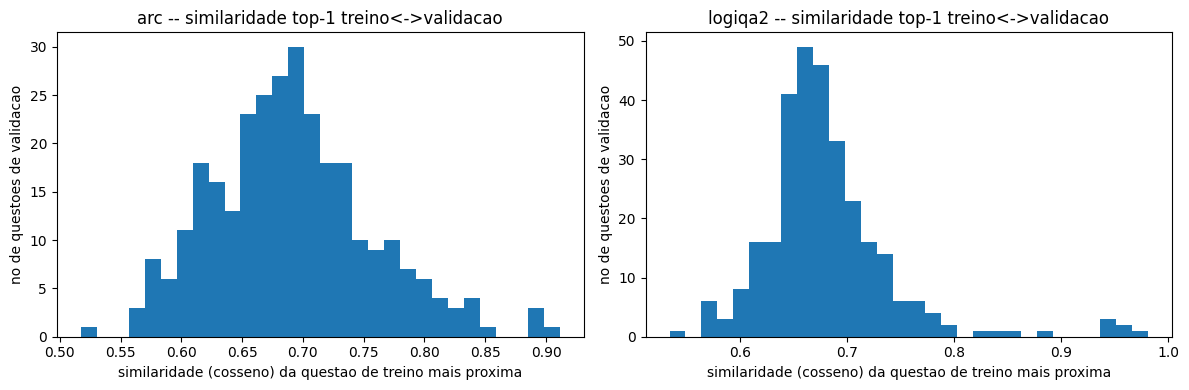

,arc,logiqa2
count,298.000000,300.000000
mean,0.690866,0.681467
std,0.065870,0.061765
min,0.517296,0.534345
10%,0.612401,0.621383
25%,0.647497,0.649400
50%,0.687178,0.672291
75%,0.728545,0.701636
90%,0.779179,0.740497
95%,0.813063,0.782628


In [19]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 4))
axes = np.atleast_1d(axes)
top1_sim_by_ds = {}

for ax, dataset in zip(axes, DATASETS):
    top1 = sim_matrix_by_ds[dataset].max(axis=1)
    top1_sim_by_ds[dataset] = top1
    ax.hist(top1, bins=30)
    ax.set_xlabel("similaridade (cosseno) da questao de treino mais proxima")
    ax.set_ylabel("no de questoes de validacao")
    ax.set_title(f"{dataset} -- similaridade top-1 treino<->validacao")

plt.tight_layout()
plt.show()

pd.DataFrame({d: pd.Series(top1_sim_by_ds[d]).describe(percentiles=[.1, .25, .5, .75, .9, .95]) for d in DATASETS})

## 7. Escolha de `k` e do limiar, por dataset, e recuperação

Data-driven, como em `03`/`04`: os limiares candidatos vêm dos quartis da distribuição de
similaridade top-1 de cada dataset (seção 6) — calculados separadamente, porque ARC e LogiQA2
têm distribuições diferentes.

In [20]:
K_GRID = [1, 2, 3]  # mesmos candidatos de 03/04 (rmcq.config.K_CANDIDATES inclui 1 e 3; 2 foi pedido a mais)

THRESHOLD_GRID_BY_DS = {}
for dataset in DATASETS:
    quantiles = [0.0, 0.25, 0.5, 0.75]
    THRESHOLD_GRID_BY_DS[dataset] = sorted({0.0} | {round(float(np.quantile(top1_sim_by_ds[dataset], q)), 2) for q in quantiles})
    print(f"[{dataset}] THRESHOLD_GRID = {THRESHOLD_GRID_BY_DS[dataset]}")

n_configs = sum(
    len(STUDENTS) * len(DEPTHS) * len(K_GRID) * len(THRESHOLD_GRID_BY_DS[d]) for d in DATASETS
)
print(f"\ntotal de configuracoes (todos os datasets): {n_configs}")

[arc] THRESHOLD_GRID = [0.0, 0.52, 0.65, 0.69, 0.73]
[logiqa2] THRESHOLD_GRID = [0.0, 0.53, 0.65, 0.67, 0.7]

total de configuracoes (todos os datasets): 120


In [21]:
def retrieve_neighbors(sims_row, train_uids, k, threshold, allowed_train_uids=None):
    """Ate k vizinhos de treino com similaridade >= threshold, em ordem CRESCENTE de similaridade.

    Identica a rmcq.retrieval na politica (mais similar por ultimo, perto de onde a geracao
    comeca) -- reescrita aqui porque opera sobre a matriz de similaridade v2 (secao 6), nao
    sobre o indice oficial que rmcq.retrieval.build conhece.
    """
    order = np.argsort(-sims_row)
    picked = []
    for idx in order:
        sim = float(sims_row[idx])
        if sim < threshold:
            break
        uid = train_uids[idx]
        if allowed_train_uids is not None and uid not in allowed_train_uids:
            continue
        picked.append((uid, sim))
        if len(picked) >= k:
            break
    picked.reverse()
    return picked


# Pre-visualizacao SEM chamar nenhum modelo: quantas reflexoes cada (dataset, k, threshold)
# realmente entrega, e em que fracao dos itens de validacao a busca nao encontra nada acima do
# limiar (cai no baseline puro). Vale olhar isto antes de gastar GPU na grade completa.
coverage_rows = []
for dataset in DATASETS:
    for student in STUDENTS:
        for depth in DEPTHS:
            refl = REFLECTIONS_V2[(dataset, student, depth)]
            allowed = {u for u, r in refl.items() if r.get("reflection_text")}
            for k in K_GRID:
                for threshold in THRESHOLD_GRID_BY_DS[dataset]:
                    counts = np.array([
                        len(retrieve_neighbors(sim_matrix_by_ds[dataset][val_uid_to_row_by_ds[dataset][u]], train_uids_by_ds[dataset], k, threshold, allowed))
                        for u in val_uids_by_ds[dataset]
                    ])
                    coverage_rows.append({
                        "dataset": dataset, "student": student, "depth": depth, "k": k, "threshold": threshold,
                        "mean_retrieved": counts.mean(),
                        "pct_full_k": (counts == k).mean(),
                        "pct_zero_fallback_baseline": (counts == 0).mean(),
                    })

coverage_df = pd.DataFrame(coverage_rows)
coverage_df.round(3).head(20)

,dataset,student,depth,k,threshold,mean_retrieved,pct_full_k,pct_zero_fallback_baseline
0,arc,phi4-mini,simple,1,0.00,1.000,1.000,0.000
1,arc,phi4-mini,simple,1,0.52,0.997,0.997,0.003
2,arc,phi4-mini,simple,1,0.65,0.732,0.732,0.268
3,arc,phi4-mini,simple,1,0.69,0.477,0.477,0.523
4,arc,phi4-mini,simple,1,0.73,0.242,0.242,0.758
5,arc,phi4-mini,simple,2,0.00,2.000,1.000,0.000
6,arc,phi4-mini,simple,2,0.52,1.993,0.997,0.003
7,arc,phi4-mini,simple,2,0.65,1.265,0.534,0.268
8,arc,phi4-mini,simple,2,0.69,0.715,0.238,0.523
9,arc,phi4-mini,simple,2,0.73,0.319,0.077,0.758


O prompt de avaliação em si (como as notas recuperadas viram texto) é `rmcq.common.build_eval_prompt`,
importado sem cópia local (seção 2). O exemplo abaixo mostra o prompt exato que o aluno recebe,
com `k=2` e sem filtro de limiar, usando as reflexões novas desta rodada.

In [22]:
_ds = "arc"
_student = STUDENTS[0]
_sample = val_selected[_ds][0]
_refl = REFLECTIONS_V2[(_ds, _student, "simple")]
_allowed = {u for u, r in _refl.items() if r.get("reflection_text")}
_picked = retrieve_neighbors(sim_matrix_by_ds[_ds][val_uid_to_row_by_ds[_ds][_sample["uid"]]], train_uids_by_ds[_ds], k=2, threshold=0.0, allowed_train_uids=_allowed)
_texts = [_refl[u]["reflection_text"] for u, _ in _picked]
_srcq = [format_question(train_by_uid_by_ds[_ds][u]) for u, _ in _picked]
_srcc = [_refl[u].get("extra", {}).get("source_was_correct") for u, _ in _picked]

print(build_eval_prompt(_sample, _texts, _srcq, _srcc))

You are answering a multiple-choice question.

First, some notes from earlier attempts at OTHER questions. They are reference material about how to reason. None of them is about the question below, and none of them contains its answer.

<notes>
<note id="1">
This note was written about a different question: "A student compared the speeds at which a large and a small marble rolled down an inclined plane. In order to make the findings more reliable, the student should"
The earlier answer to that question was correct.
In my previous reasoning, I focused on the importance of consistency in the experimental conditions to ensure the variable being tested (the size of the marbles) is the primary factor influencing the outcome. By repeating the experiment, I aimed to eliminate anomalies and obtain a more reliable average result, which is a key factor in making the findings more consistent and reliable. My reasoning was sound because I correctly identified that multiple trials can help average 

## 8. Rodando a grade `dataset × k × threshold × depth`

Cada configuração é `(dataset, aluno, profundidade, k, threshold)` — professor == aluno sempre
(seção 0). Agrupado por aluno para carregar cada modelo uma única vez (como
`rmcq.stages.evaluate`), cobrindo os dois datasets e as duas profundidades nessa mesma carga.
Grava em `results/reflection_v2/diagnostics/<aluno>__<aluno>__<profundidade>__k<k>__t<threshold>/<dataset>_validation.jsonl`,
retomável do jeito de sempre.

Com `SMOKE_TEST = True` isto roda em segundos. Para a rodada de verdade, `SMOKE_TEST = False`,
reinicie a partir da célula de setup (seção 0) e rode esta célula — pode levar horas, é
esperado (mais ainda que `03`/`04`: dois datasets em vez de um).

In [23]:
GRID = [
    {"dataset": ds, "student": s, "depth": d, "k": k, "threshold": thr}
    for ds in DATASETS
    for s in STUDENTS
    for d in DEPTHS
    for k in K_GRID
    for thr in THRESHOLD_GRID_BY_DS[ds]
]

n_items_total = sum(len(val_selected[ds][:RUN_LIMIT] if RUN_LIMIT else val_selected[ds]) for ds in DATASETS)
print(f"{len(GRID)} configuracoes, {n_items_total} itens de validacao (somando os dois datasets)")


def diag_tag(student, depth, k, threshold):
    t_tag = f"t{threshold:.2f}".replace(".", "p")
    return f"{student}__{student}__{depth}__k{k}__{t_tag}"


def diag_eval_path(dataset, student, depth, k, threshold):
    d = DIAG_V2_DIR / diag_tag(student, depth, k, threshold)
    d.mkdir(parents=True, exist_ok=True)
    return d / f"{dataset}_validation.jsonl"


def run_diagnostic_grid_v2(grid, limit=None, backend_kind=None):
    from collections import defaultdict

    items_by_ds = {ds: (val_selected[ds][:limit] if limit else val_selected[ds]) for ds in DATASETS}
    items_by_uid_by_ds = {ds: {i["uid"]: i for i in items_by_ds[ds]} for ds in DATASETS}

    by_student = defaultdict(list)
    for cfg in grid:
        by_student[cfg["student"]].append(cfg)

    params = GenParams.from_config(STUDENT_GEN, seed=SEED)
    stats = {"generated": 0, "elapsed_s": 0.0}

    for student, cfgs in by_student.items():
        work = []
        for cfg in cfgs:
            path = diag_eval_path(cfg["dataset"], student, cfg["depth"], cfg["k"], cfg["threshold"])
            done = JsonlStore(path).done_keys()
            use_uids = list(items_by_uid_by_ds[cfg["dataset"]])
            pending_uids = [u for u in use_uids if u not in done]
            if pending_uids:
                work.append((cfg, path, pending_uids))

        if not work:
            log.info("[aluno=%s] nada a fazer", student)
            continue

        with Timer() as timer, get_backend(student, backend_kind) as backend:
            for cfg, path, pending_uids in work:
                dataset, depth, k, threshold = cfg["dataset"], cfg["depth"], cfg["k"], cfg["threshold"]
                store = JsonlStore(path)

                refl = REFLECTIONS_V2[(dataset, student, depth)]
                allowed = {u for u, r in refl.items() if r.get("reflection_text")}
                items_by_uid = items_by_uid_by_ds[dataset]

                prompts, metas = [], []
                for uid in pending_uids:
                    picked = retrieve_neighbors(sim_matrix_by_ds[dataset][val_uid_to_row_by_ds[dataset][uid]], train_uids_by_ds[dataset], k, threshold, allowed)
                    texts = [refl[u]["reflection_text"] for u, _ in picked]
                    src_qs = [format_question(train_by_uid_by_ds[dataset][u]) for u, _ in picked]
                    src_correct = [refl[u].get("extra", {}).get("source_was_correct") for u, _ in picked]

                    item = items_by_uid[uid]
                    prompts.append(build_eval_prompt(item, texts, src_qs, src_correct))
                    metas.append((item, [u for u, _ in picked], [s for _, s in picked]))

                gens = backend.generate(prompts, params, desc=f"{student} diag-v2 {dataset}/{depth}/k{k}/t{threshold:.2f}")

                records = [
                    make_record(
                        item, stage="eval_diagnostic", condition="self_reflection", student_model=student,
                        teacher_model=student, prompt=prompt, output=gen.text,
                        reflection_depth=depth, reflection_perspective="student",
                        retrieved_uids=used_uids, retrieved_similarities=[round(x, 6) for x in sims],
                        k=k, prompt_tokens=gen.prompt_tokens, completion_tokens=gen.completion_tokens,
                        latency_s=gen.latency_s, seed=SEED, temperature=params.temperature,
                        extra={
                            "threshold": threshold,
                            "top1_similarity": max(sims) if sims else None,
                            "mean_similarity": (sum(sims) / len(sims)) if sims else None,
                            "n_reflections_injected": len(used_uids),
                            "fallback_to_baseline": len(used_uids) == 0,
                            "reflection_prompt_version": "v2_gabarito",
                        },
                    )
                    for (item, used_uids, sims), prompt, gen in zip(metas, prompts, gens)
                ]
                store.append(records)
                stats["generated"] += len(records)

                n_ok = sum(1 for r in records if r.is_correct)
                log.info("  [%s] %s/%s/k%d/t%.2f: %d respostas, acerto %.1f%%", student, dataset, depth, k, threshold, len(records), 100 * n_ok / max(len(records), 1))
        stats["elapsed_s"] += timer.elapsed

    return stats


run_diagnostic_grid_v2(GRID, limit=RUN_LIMIT, backend_kind=BACKEND_KIND)

01:19:17 INFO    carregando phi4-mini (microsoft/Phi-4-mini-instruct) via vLLM  tp=1  gpu_util=0.60


120 configuracoes, 598 itens de validacao (somando os dois datasets)
INFO 08-27 01:19:17 [api_utils.py:273] non-default args: {'tokenizer': 'microsoft/Phi-4-mini-instruct', 'download_dir': '/home/rodrigo.flexa/Reflection-MCQ/models/hf_cache', 'dtype': 'bfloat16', 'seed': 42, 'max_model_len': 8192, 'gpu_memory_utilization': 0.6, 'disable_log_stats': True, 'model': 'microsoft/Phi-4-mini-instruct'}
INFO 08-27 01:19:17 [model.py:645] Resolved architecture: Phi3ForCausalLM
INFO 08-27 01:19:17 [model.py:1883] Using max model len 8192
INFO 08-27 01:19:17 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
WARNING 08-27 01:19:20 [system_utils.py:157] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
(EngineCore pid=10

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


(EngineCore pid=1052333) INFO 08-27 01:19:45 [weight_utils.py:801] Prefetching checkpoint files: 10% (1/2)


Loading safetensors checkpoint shards:  50% Completed | 1/2 [00:00<00:00,  1.13it/s]


...

Processed prompts: 100%|██████████| 300/300 [00:12<00:00, 24.07it/s, est. speed input: 13378.41 toks/s, output: 2470.89 toks/s]
01:56:05 INFO      300 prompts, 30786 tokens gerados em 12.5s (2457 tok/s)


Rendering prompts:   0%|          | 0/300 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 300/300 [00:12<00:00, 23.33it/s, est. speed input: 8764.14 toks/s, output: 2339.32 toks/s] 
01:56:18 INFO      300 prompts, 30075 tokens gerados em 12.9s (2326 tok/s)
01:56:18 INFO    liberando llama3-8b


INFO 08-27 01:56:18 [utils.py:612] [shutdown] Process manager: send sigterm to process EngineCore
(EngineCore pid=1079856) INFO 08-27 01:56:18 [core.py:1332] [shutdown] EngineCore: trigger received signal=SIGTERM
(EngineCore pid=1079856) INFO 08-27 01:56:18 [core.py:1468] [shutdown] EngineCore: start mode=abort timeout=0s
(EngineCore pid=1079856) INFO 08-27 01:56:18 [core.py:1499] [shutdown] EngineCore: request processing complete; starting resource teardown
(EngineCore pid=1079856) INFO 08-27 01:56:18 [core.py:1345] [shutdown] EngineCore: exiting busy loop


{'generated': 35880, 'elapsed_s': 2226.542145241052}

## 9. Consolidação — acurácia, reflection utility, McNemar

`rmcq.stages.analyze.utility` (mesma métrica de `analysis.ipynb` e de `03`/`04`): taxa de
virada errado→certo menos certo→errado, contra o baseline de validação novo (seção 3), item a
item. McNemar exato (`scipy.stats.binomtest`) porque baseline e condição respondem os MESMOS
itens.

In [24]:
records = []
for cfg in GRID:
    path = diag_eval_path(cfg["dataset"], cfg["student"], cfg["depth"], cfg["k"], cfg["threshold"])
    rows = load_rows(path)
    if not rows:
        continue

    base = baseline_val_v2[(cfg["student"], cfg["dataset"])]
    u = utility(base, rows)
    acc = accuracy_block(list(rows.values()))
    n_retrieved = [(r.get("extra") or {}).get("n_reflections_injected", len(r.get("retrieved_uids") or [])) for r in rows.values()]

    records.append({
        **cfg, **u,
        "accuracy": acc["accuracy"], "accuracy_answered": acc["accuracy_answered"],
        "mean_retrieved": float(np.mean(n_retrieved)) if n_retrieved else 0.0,
        "pct_fallback_baseline": float(np.mean([n == 0 for n in n_retrieved])) if n_retrieved else None,
    })

summary_df = pd.DataFrame(records)

try:
    from scipy.stats import binomtest

    def _mcnemar_p(row):
        b, c = row["wrong_to_right"], row["right_to_wrong"]
        return 1.0 if b + c == 0 else binomtest(min(b, c), b + c, 0.5).pvalue

    summary_df["mcnemar_p"] = summary_df.apply(_mcnemar_p, axis=1) if not summary_df.empty else None
except ImportError:
    warnings.warn("scipy indisponivel: mcnemar_p nao calculado")
    summary_df["mcnemar_p"] = None

summary_df.sort_values("utility", ascending=False).round(4)

,dataset,student,depth,k,threshold,n_shared,wrong_to_right,right_to_wrong,kept_right,kept_wrong,rate_wrong_to_right,rate_right_to_wrong,utility,baseline_accuracy,condition_accuracy,delta_accuracy,accuracy,accuracy_answered,mean_retrieved,pct_fallback_baseline,mcnemar_p
73,logiqa2,phi4-mini,simple,3,0.67,300,25,17,143,115,0.0833,0.0567,0.0267,0.5333,0.5600,0.0267,0.5600,0.5600,1.1133,0.4833,0.2800
104,logiqa2,llama3-8b,simple,3,0.70,300,17,10,155,118,0.0567,0.0333,0.0233,0.5500,0.5733,0.0233,0.5733,0.5753,0.4500,0.7367,0.2478
64,logiqa2,phi4-mini,simple,1,0.70,300,20,14,146,120,0.0667,0.0467,0.0200,0.5333,0.5533,0.0200,0.5533,0.5533,0.2633,0.7367,0.3915
72,logiqa2,phi4-mini,simple,3,0.65,300,27,21,139,113,0.0900,0.0700,0.0200,0.5333,0.5533,0.0200,0.5533,0.5533,1.6867,0.2667,0.4709
98,logiqa2,llama3-8b,simple,2,0.67,300,23,18,147,112,0.0767,0.0600,0.0167,0.5500,0.5667,0.0167,0.5667,0.5686,0.8567,0.4833,0.5327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,logiqa2,phi4-mini,simple,3,0.53,300,27,40,120,113,0.0900,0.1333,-0.0433,0.5333,0.4900,-0.0433,0.4900,0.4900,2.9933,0.0000,0.1421
111,logiqa2,llama3-8b,complex,2,0.53,300,24,38,127,111,0.0800,0.1267,-0.0467,0.5500,0.5033,-0.0467,0.5033,0.5067,2.0000,0.0000,0.0980
115,logiqa2,llama3-8b,complex,3,0.00,300,30,45,120,105,0.1000,0.1500,-0.0500,0.5500,0.5000,-0.0500,0.5000,0.5034,3.0000,0.0000,0.1053
56,arc,llama3-8b,complex,3,0.52,298,15,35,217,31,0.0503,0.1174,-0.0671,0.8456,0.7785,-0.0671,0.7785,0.7785,2.9899,0.0034,0.0066


### Comparação com a rodada v1 (`03`/`04`, reflexões antigas, feedback sem gabarito)

Se `03`/`04` já tiverem sido rodados de verdade (`SMOKE_TEST = False` lá), os CSVs
`results/diagnostics/summary_<dataset>_validation.csv` existem e trazem a mesma métrica de
utility para a MESMA grade de `k`/`threshold`, só que com a reflexão antiga. A tabela abaixo
junta v1 e v2 pela melhor configuração de cada `(dataset, aluno, profundidade)` — é a
comparação que testa a hipótese da seção 0 diretamente: **prompts + feedback novos bateram os
antigos, no mesmo ponto de comparação?** Se os CSVs de v1 não existirem ainda (rodada real não
feita), a célula avisa e segue só com v2.

In [25]:
v1_frames = []
for dataset in DATASETS:
    v1_path = RESULTS_DIR / "diagnostics" / f"summary_{dataset}_validation.csv"
    if v1_path.exists():
        df = pd.read_csv(v1_path)
        df["dataset"] = dataset
        v1_frames.append(df)
    else:
        warnings.warn(f"{v1_path} nao existe ainda -- rode 03/04 com SMOKE_TEST=False para ter a comparacao v1 x v2 de {dataset}")

if v1_frames and not summary_df.empty:
    v1_df = pd.concat(v1_frames, ignore_index=True)
    v1_best = v1_df.loc[v1_df.groupby(["dataset", "student", "depth"])["utility"].idxmax()]
    v2_best = summary_df.loc[summary_df.groupby(["dataset", "student", "depth"])["utility"].idxmax()]

    compare = v1_best.merge(v2_best, on=["dataset", "student", "depth"], suffixes=("_v1", "_v2"))
    compare["delta_utility_v2_menos_v1"] = compare["utility_v2"] - compare["utility_v1"]
    compare[[
        "dataset", "student", "depth", "k_v1", "threshold_v1", "utility_v1",
        "k_v2", "threshold_v2", "utility_v2", "delta_utility_v2_menos_v1",
    ]].round(4)
else:
    print("comparacao v1 x v2 pulada (sem CSVs de v1 e/ou sem resultados de v2 ainda -- normal em SMOKE_TEST)")

### Tabela: configurações que superaram o baseline

In [26]:
wins = summary_df[summary_df["utility"] > 0].sort_values("utility", ascending=False) if not summary_df.empty else summary_df
cols = [
    "dataset", "student", "depth", "k", "threshold", "n_shared", "mean_retrieved", "pct_fallback_baseline",
    "baseline_accuracy", "condition_accuracy", "delta_accuracy", "utility", "wrong_to_right", "right_to_wrong", "mcnemar_p",
]
wins_display = wins[[c for c in cols if c in wins.columns]].round(4) if not wins.empty else wins

print(f"{len(wins_display)} de {len(summary_df)} configuracoes superaram o baseline (utility > 0)")
wins_display

15 de 120 configuracoes superaram o baseline (utility > 0)


,dataset,student,depth,k,threshold,n_shared,mean_retrieved,pct_fallback_baseline,baseline_accuracy,condition_accuracy,delta_accuracy,utility,wrong_to_right,right_to_wrong,mcnemar_p
73,logiqa2,phi4-mini,simple,3,0.67,300,1.1133,0.4833,0.5333,0.5600,0.0267,0.0267,25,17,0.2800
104,logiqa2,llama3-8b,simple,3,0.70,300,0.4500,0.7367,0.5500,0.5733,0.0233,0.0233,17,10,0.2478
64,logiqa2,phi4-mini,simple,1,0.70,300,0.2633,0.7367,0.5333,0.5533,0.0200,0.0200,20,14,0.3915
72,logiqa2,phi4-mini,simple,3,0.65,300,1.6867,0.2667,0.5333,0.5533,0.0200,0.0200,27,21,0.4709
98,logiqa2,llama3-8b,simple,2,0.67,300,0.8567,0.4833,0.5500,0.5667,0.0167,0.0167,23,18,0.5327
99,logiqa2,llama3-8b,simple,2,0.70,300,0.3967,0.7367,0.5500,0.5633,0.0133,0.0133,15,11,0.5572
108,logiqa2,llama3-8b,complex,1,0.67,300,0.5167,0.4833,0.5500,0.5633,0.0133,0.0133,22,18,0.6358
114,logiqa2,llama3-8b,complex,2,0.70,300,0.3967,0.7367,0.5500,0.5600,0.0100,0.0100,17,14,0.7201
103,logiqa2,llama3-8b,simple,3,0.67,300,1.1133,0.4833,0.5500,0.5600,0.0100,0.0100,21,18,0.7493
63,logiqa2,phi4-mini,simple,1,0.67,300,0.5167,0.4833,0.5333,0.5400,0.0067,0.0067,22,20,0.8776


In [27]:
summary_df.to_csv(DIAG_V2_DIR / "summary_all_datasets.csv", index=False)
wins_display.to_csv(DIAG_V2_DIR / "wins_all_datasets.csv", index=False)
print(f"gravado: {DIAG_V2_DIR / 'summary_all_datasets.csv'}")
print(f"gravado: {DIAG_V2_DIR / 'wins_all_datasets.csv'}")

gravado: /home/rodrigo.flexa/Reflection-MCQ/results/reflection_v2/diagnostics/summary_all_datasets.csv
gravado: /home/rodrigo.flexa/Reflection-MCQ/results/reflection_v2/diagnostics/wins_all_datasets.csv


## 10. Gráficos

### Acurácia vs. limiar de similaridade, por k (linha horizontal = baseline)

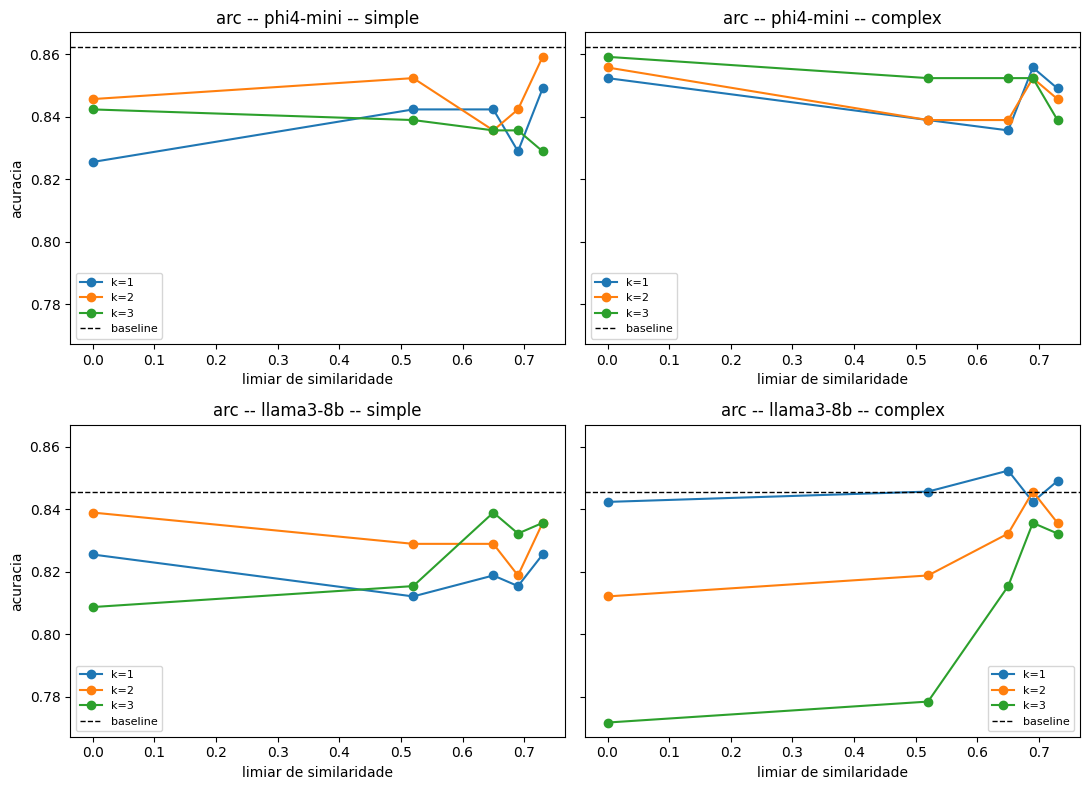

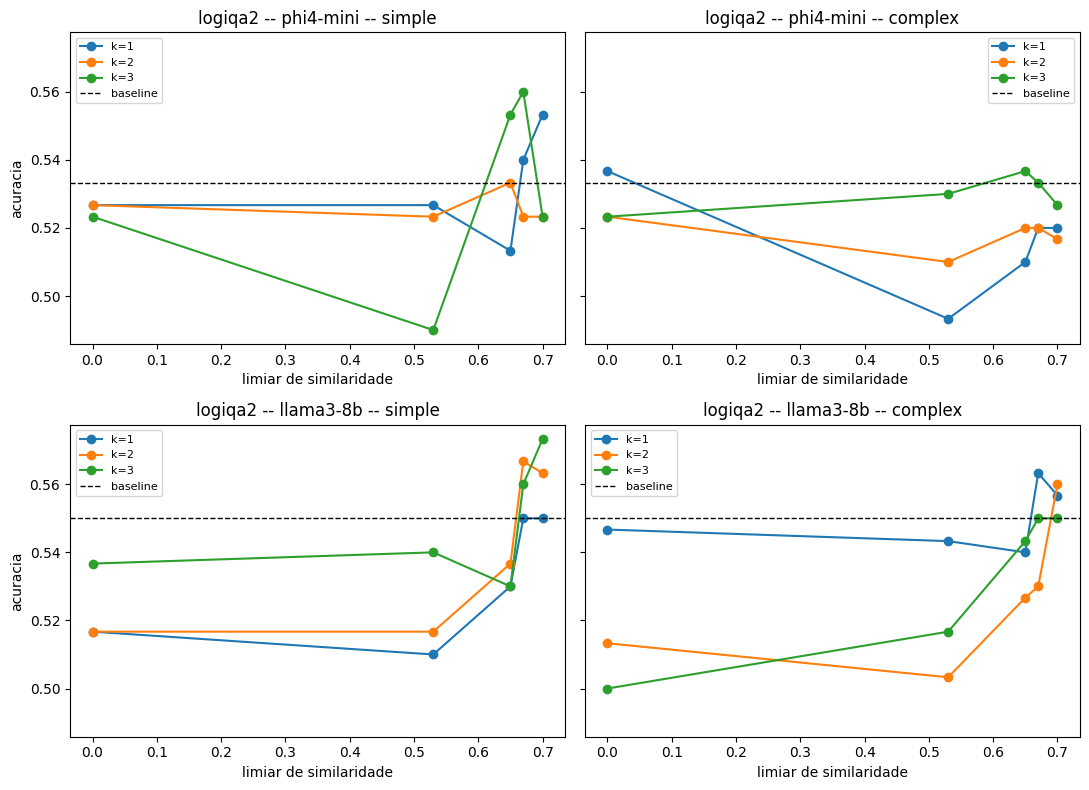

In [28]:
for dataset in DATASETS:
    sub_all = summary_df[summary_df["dataset"] == dataset]
    if sub_all.empty:
        print(f"[{dataset}] sem resultados ainda, pulando grafico")
        continue

    fig, axes = plt.subplots(len(STUDENTS), len(DEPTHS), figsize=(11, 4 * len(STUDENTS)), sharey=True)
    axes = np.atleast_2d(axes)

    for i, student in enumerate(STUDENTS):
        base_acc = accuracy_block(list(baseline_val_v2[(student, dataset)].values()))["accuracy"]
        for j, depth in enumerate(DEPTHS):
            ax = axes[i, j]
            sub = sub_all[(sub_all["student"] == student) & (sub_all["depth"] == depth)]
            for k in sorted(sub["k"].unique()):
                line = sub[sub["k"] == k].sort_values("threshold")
                ax.plot(line["threshold"], line["accuracy"], marker="o", label=f"k={k}")
            ax.axhline(base_acc, color="black", linestyle="--", linewidth=1, label="baseline")
            ax.set_title(f"{dataset} -- {student} -- {depth}")
            ax.set_xlabel("limiar de similaridade")
            if j == 0:
                ax.set_ylabel("acuracia")
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

### Mapa de calor: delta de acurácia (condição − baseline) por k × limiar

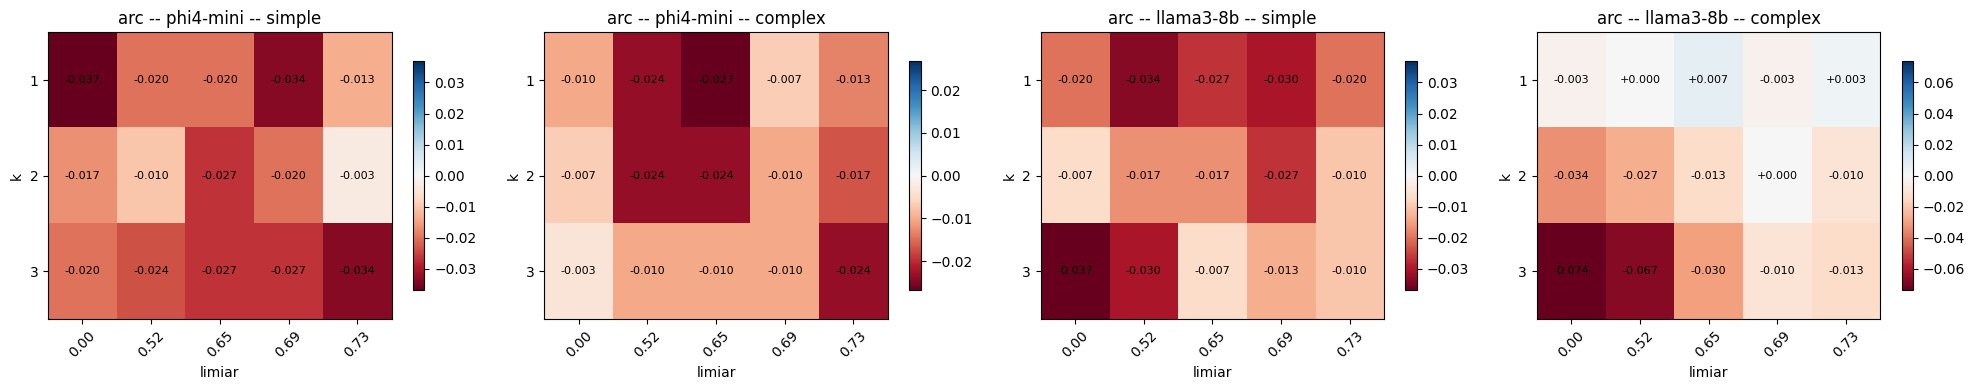

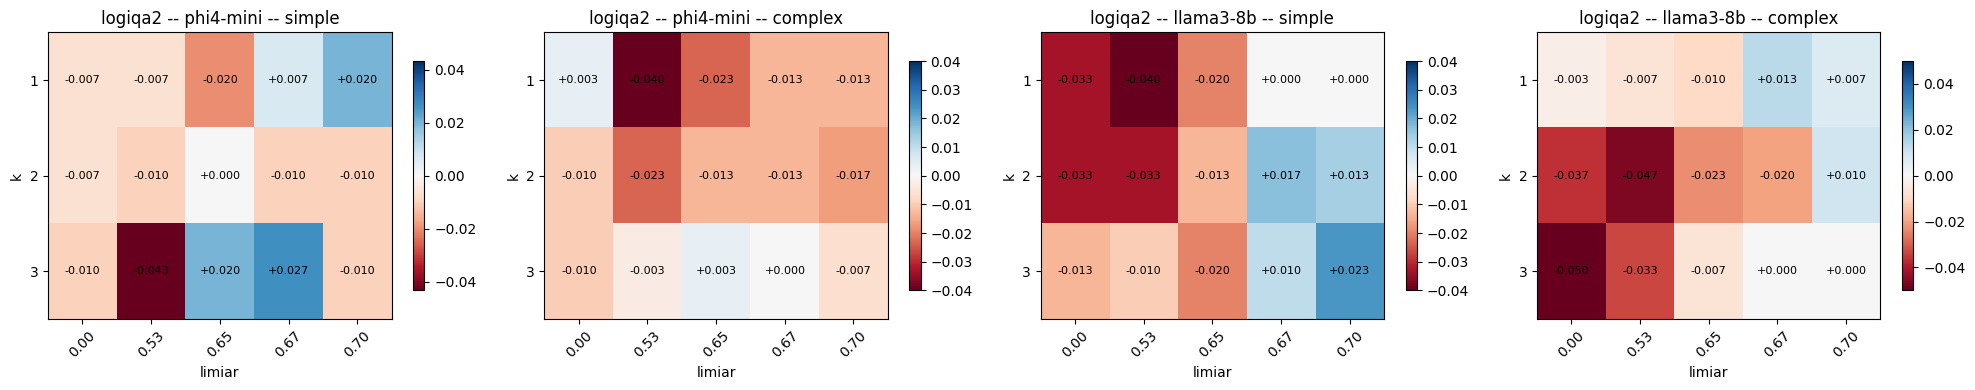

In [29]:
for dataset in DATASETS:
    sub_all = summary_df[summary_df["dataset"] == dataset]
    if sub_all.empty:
        continue

    fig, axes = plt.subplots(1, len(STUDENTS) * len(DEPTHS), figsize=(5 * len(STUDENTS) * len(DEPTHS), 4))
    axes = np.atleast_1d(axes)

    panel = 0
    for student in STUDENTS:
        for depth in DEPTHS:
            ax = axes[panel]
            panel += 1
            sub = sub_all[(sub_all["student"] == student) & (sub_all["depth"] == depth)]
            pivot = sub.pivot(index="k", columns="threshold", values="delta_accuracy")
            if pivot.dropna(how="all").empty:
                ax.set_title(f"{dataset} -- {student} -- {depth} (sem dados)")
                ax.axis("off")
                continue
            vmax = max(np.nanmax(np.abs(pivot.values)), 1e-6)
            im = ax.imshow(pivot.values, cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="auto")
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels([f"{t:.2f}" for t in pivot.columns], rotation=45)
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels(pivot.index)
            ax.set_xlabel("limiar")
            ax.set_ylabel("k")
            ax.set_title(f"{dataset} -- {student} -- {depth}")
            for (yi, xi), val in np.ndenumerate(pivot.values):
                ax.text(xi, yi, f"{val:+.3f}", ha="center", va="center", fontsize=8)
            fig.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    plt.show()

### Transferability: utility × similaridade (sem filtro de limiar, `threshold=0.0`)

A figura central do paper original, agora com as reflexões v2: a utility decai com a
distância semântica entre a questão de validação e a que gerou a reflexão, ou fica
achatada/negativa em toda faixa? Usa `rmcq.stages.analyze.transferability`, as mesmas faixas
de similaridade (`SIM_BINS`) do resto do projeto.

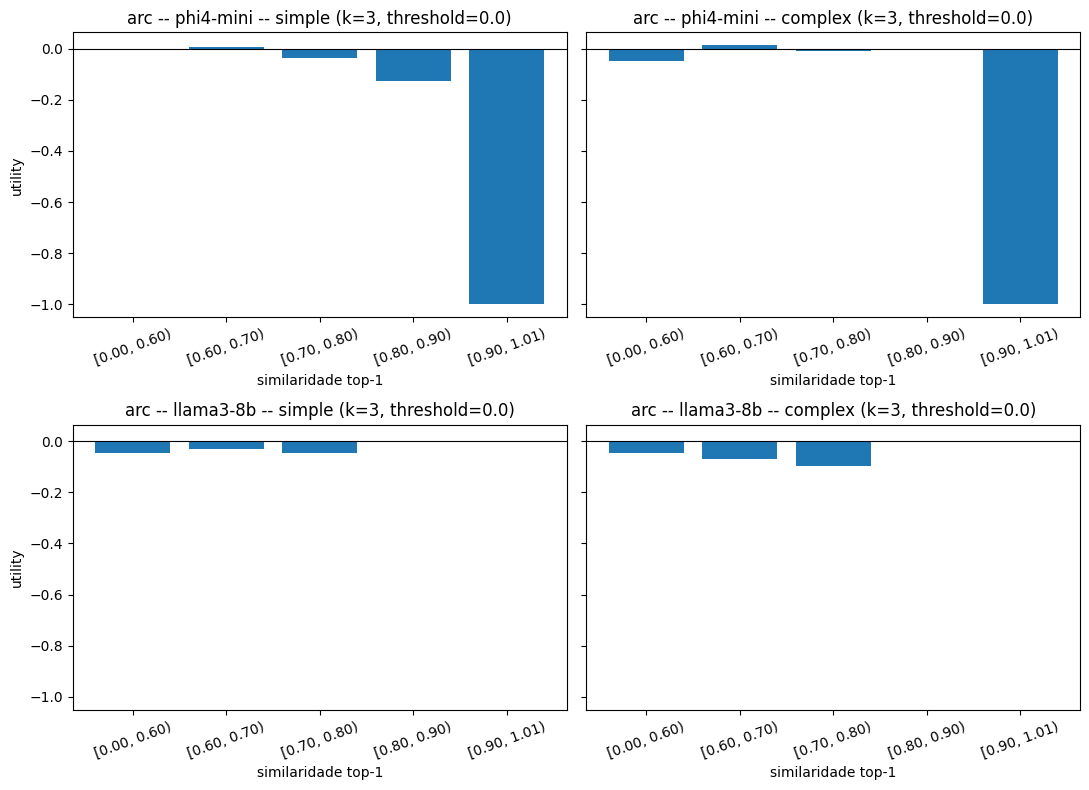

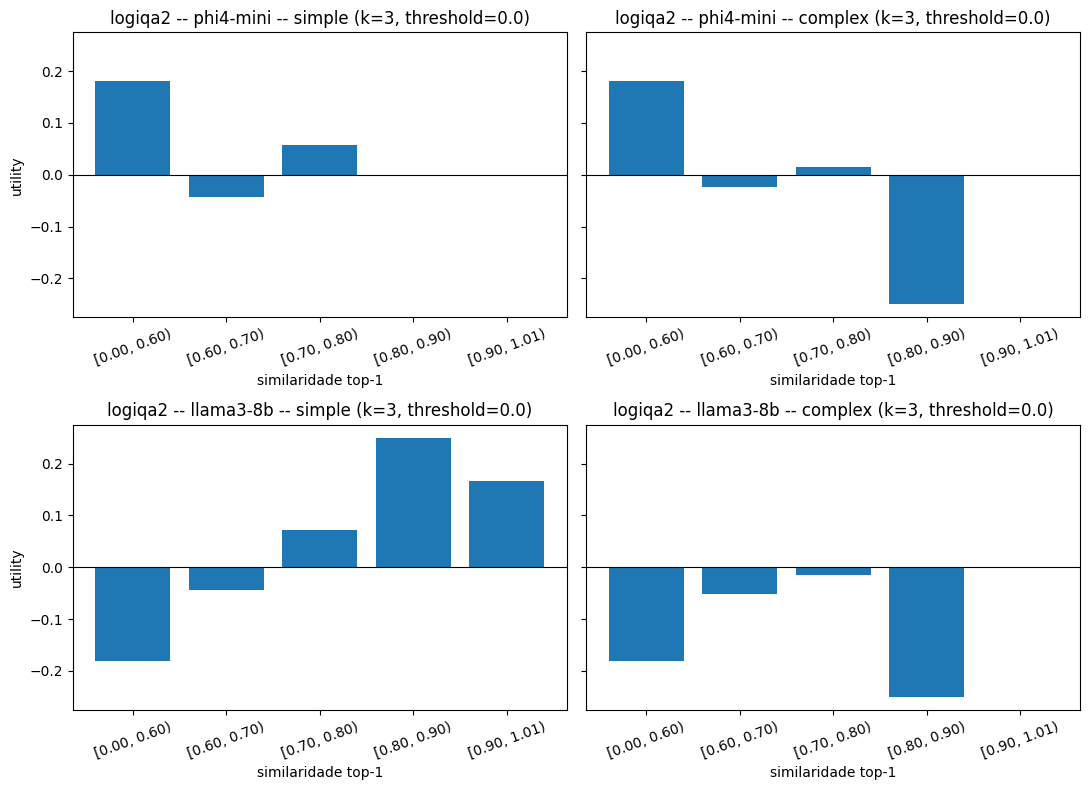

In [30]:
for dataset in DATASETS:
    fig, axes = plt.subplots(len(STUDENTS), len(DEPTHS), figsize=(11, 4 * len(STUDENTS)), sharey=True)
    axes = np.atleast_2d(axes)
    any_data = False

    for i, student in enumerate(STUDENTS):
        base = baseline_val_v2[(student, dataset)]
        for j, depth in enumerate(DEPTHS):
            ax = axes[i, j]
            k_ref = max(K_GRID)
            rows = load_rows(diag_eval_path(dataset, student, depth, k_ref, 0.0))
            if not rows:
                ax.set_title(f"{dataset} -- {student} -- {depth} (sem dados)")
                ax.axis("off")
                continue
            any_data = True
            bands = transferability(base, rows, SIM_BINS)
            band_df = pd.DataFrame(bands)
            ax.bar(band_df["sim_bin"], band_df["utility"])
            ax.axhline(0, color="black", linewidth=0.8)
            ax.set_title(f"{dataset} -- {student} -- {depth} (k={k_ref}, threshold=0.0)")
            ax.set_xlabel("similaridade top-1")
            ax.tick_params(axis="x", rotation=20)
            if j == 0:
                ax.set_ylabel("utility")

    if any_data:
        plt.tight_layout()
        plt.show()
    else:
        plt.close(fig)
        print(f"[{dataset}] sem dados para transferability ainda")

### Quantas reflexões o limiar realmente entrega

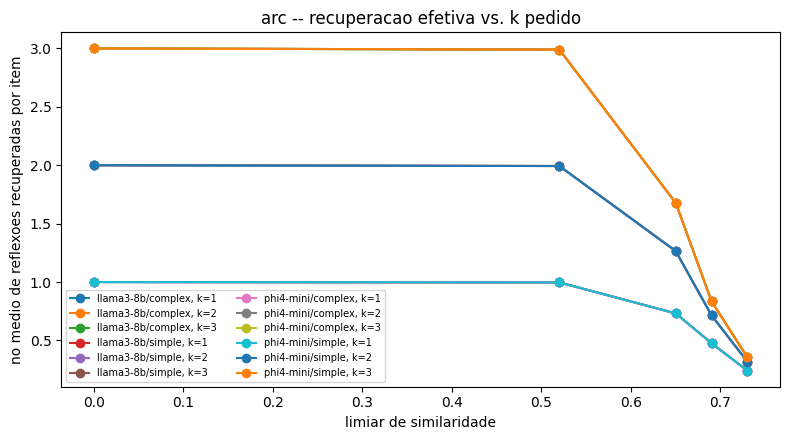

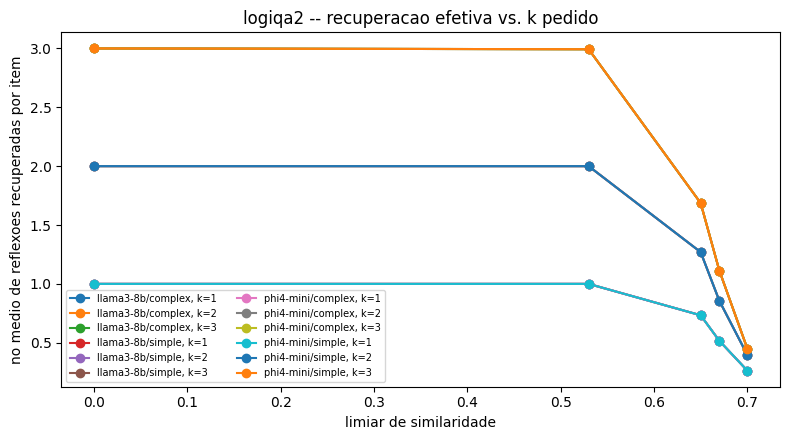

In [31]:
for dataset in DATASETS:
    sub = coverage_df[coverage_df["dataset"] == dataset]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for (student, depth), grp in sub.groupby(["student", "depth"]):
        for k in sorted(grp["k"].unique()):
            line = grp[grp["k"] == k].sort_values("threshold")
            ax.plot(line["threshold"], line["mean_retrieved"], marker="o", label=f"{student}/{depth}, k={k}")

    ax.set_xlabel("limiar de similaridade")
    ax.set_ylabel("no medio de reflexoes recuperadas por item")
    ax.set_title(f"{dataset} -- recuperacao efetiva vs. k pedido")
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()

## 11. Conclusões

Preencher depois de rodar a grade completa (não o smoke test):

- **A hipótese da seção 0 se sustenta?** A tabela de comparação v1×v2 (seção 9) mostra utility
  maior com os prompts/feedback novos, nos dois modelos e nas duas profundidades, ou o ganho
  (se houver) é específico de uma combinação? Um ganho que só aparece num
  `(dataset, aluno, profundidade)` é evidência mais fraca do que um ganho consistente.
- **O padrão de `pct_fallback_baseline` explica o resultado?** Se o limiar mais alto quase
  nunca recupera nada, a configuração "vence" só porque vira baseline disfarçado — checar antes
  de comemorar qualquer ganho (mesma ressalva de `03`/`04`).
- **Transferability (seção 10)**: a utility cai com a distância semântica, como no paper
  original, ou fica achatada/negativa em toda faixa? Isso separa "a reflexão nova transfere
  conhecimento" de "a reflexão nova só está mudando a resposta por outro motivo".
- **Inspeção qualitativa do viés de retrospecto (seção 4.2)**: antes de aceitar um ganho de
  utility como vitória do prompt novo, leia uma amostra de `results/reflection_v2/reflections/`
  — em especial os casos `source_was_correct=False` — e cheque se a "lição" é um diagnóstico de
  raciocínio de verdade ou uma racionalização em retrospecto disfarçada ("a resposta era C,
  logo lembre de C"). Se for majoritariamente o segundo caso, um ganho de utility mediria o
  modelo aprendendo a copiar padrões do gabarito, não a raciocinar melhor — vale then comparar
  com uma variante SEM o gabarito no feedback (a condição antiga) rodada com os MESMOS prompts
  novos, para separar o efeito do prompt do efeito do gabarito.
- **Only self-reflection**: como em `03`/`04`, este notebook cobre só autorreflexão. Se a
  conclusão for "nem com prompt e feedback novos a reflexão ajuda", o próximo passo natural é
  testar reflexão externa (`TEACHERS_PER_STUDENT`) antes de descartar a abordagem — para saber
  se o problema é da reflexão em si ou específico de cada modelo refletir sobre si mesmo.